In [15]:
"""
Cancer Classification with Keras (TensorFlow backend)
-------------------------------------------------------

This notebook demonstrates a basic supervised learning pipeline for binary classification
(malignant vs benign tumors) using the UCI Breast Cancer dataset (via Udemy codealong).

It covers:
- Data loading and exploration
- Data preprocessing (scaling)
- Building simple neural networks (with/without regularization)
- Training with EarlyStopping
- Model evaluation (accuracy, confusion matrix, precision, recall, F1)

All models are intentionally kept simple for educational purposes.
"""


'\nCancer Classification with Keras (TensorFlow backend)\n-------------------------------------------------------\n\nThis notebook demonstrates a basic supervised learning pipeline for binary classification\n(malignant vs benign tumors) using the UCI Breast Cancer dataset (via Udemy codealong).\n\nIt covers:\n- Data loading and exploration\n- Data preprocessing (scaling)\n- Building simple neural networks (with/without regularization)\n- Training with EarlyStopping\n- Model evaluation (accuracy, confusion matrix, precision, recall, F1)\n\nAll models are intentionally kept simple for educational purposes.\n'

In [16]:

# Import required libraries
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [17]:

DATA_PATH = '/mnt/mls/data/udemy/cancer_classification.csv'

df = pd.read_csv(DATA_PATH)


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

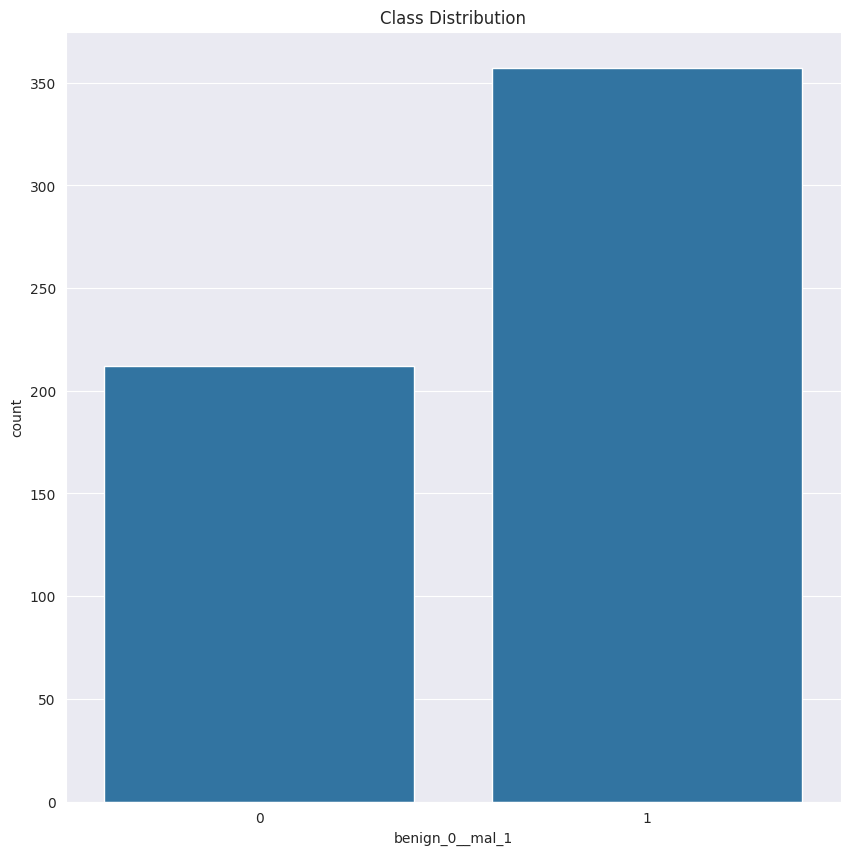

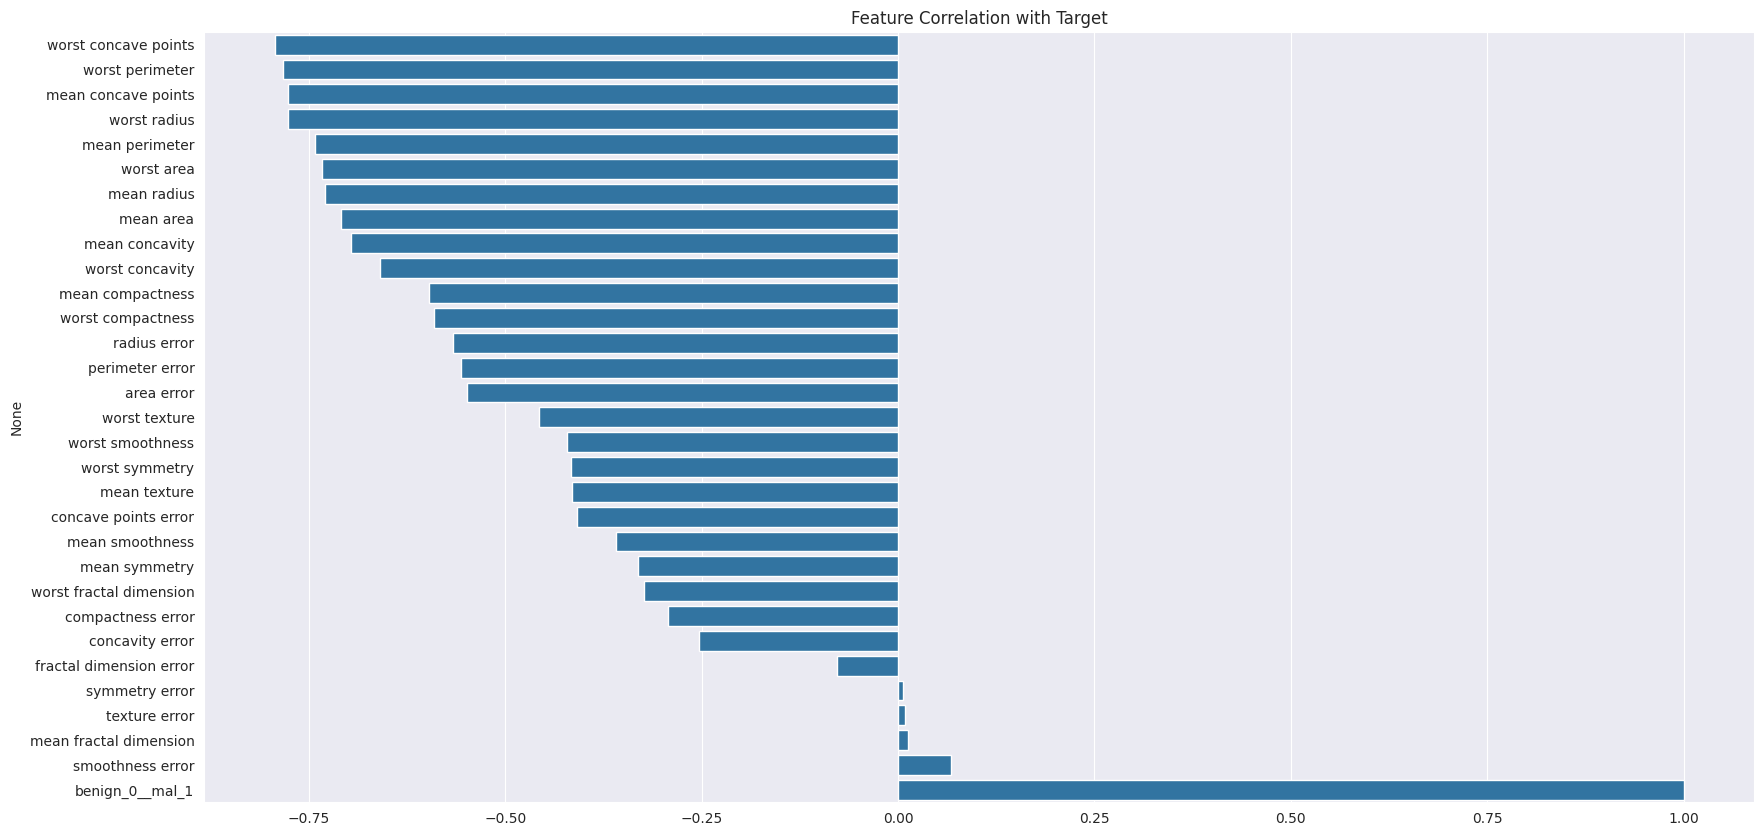

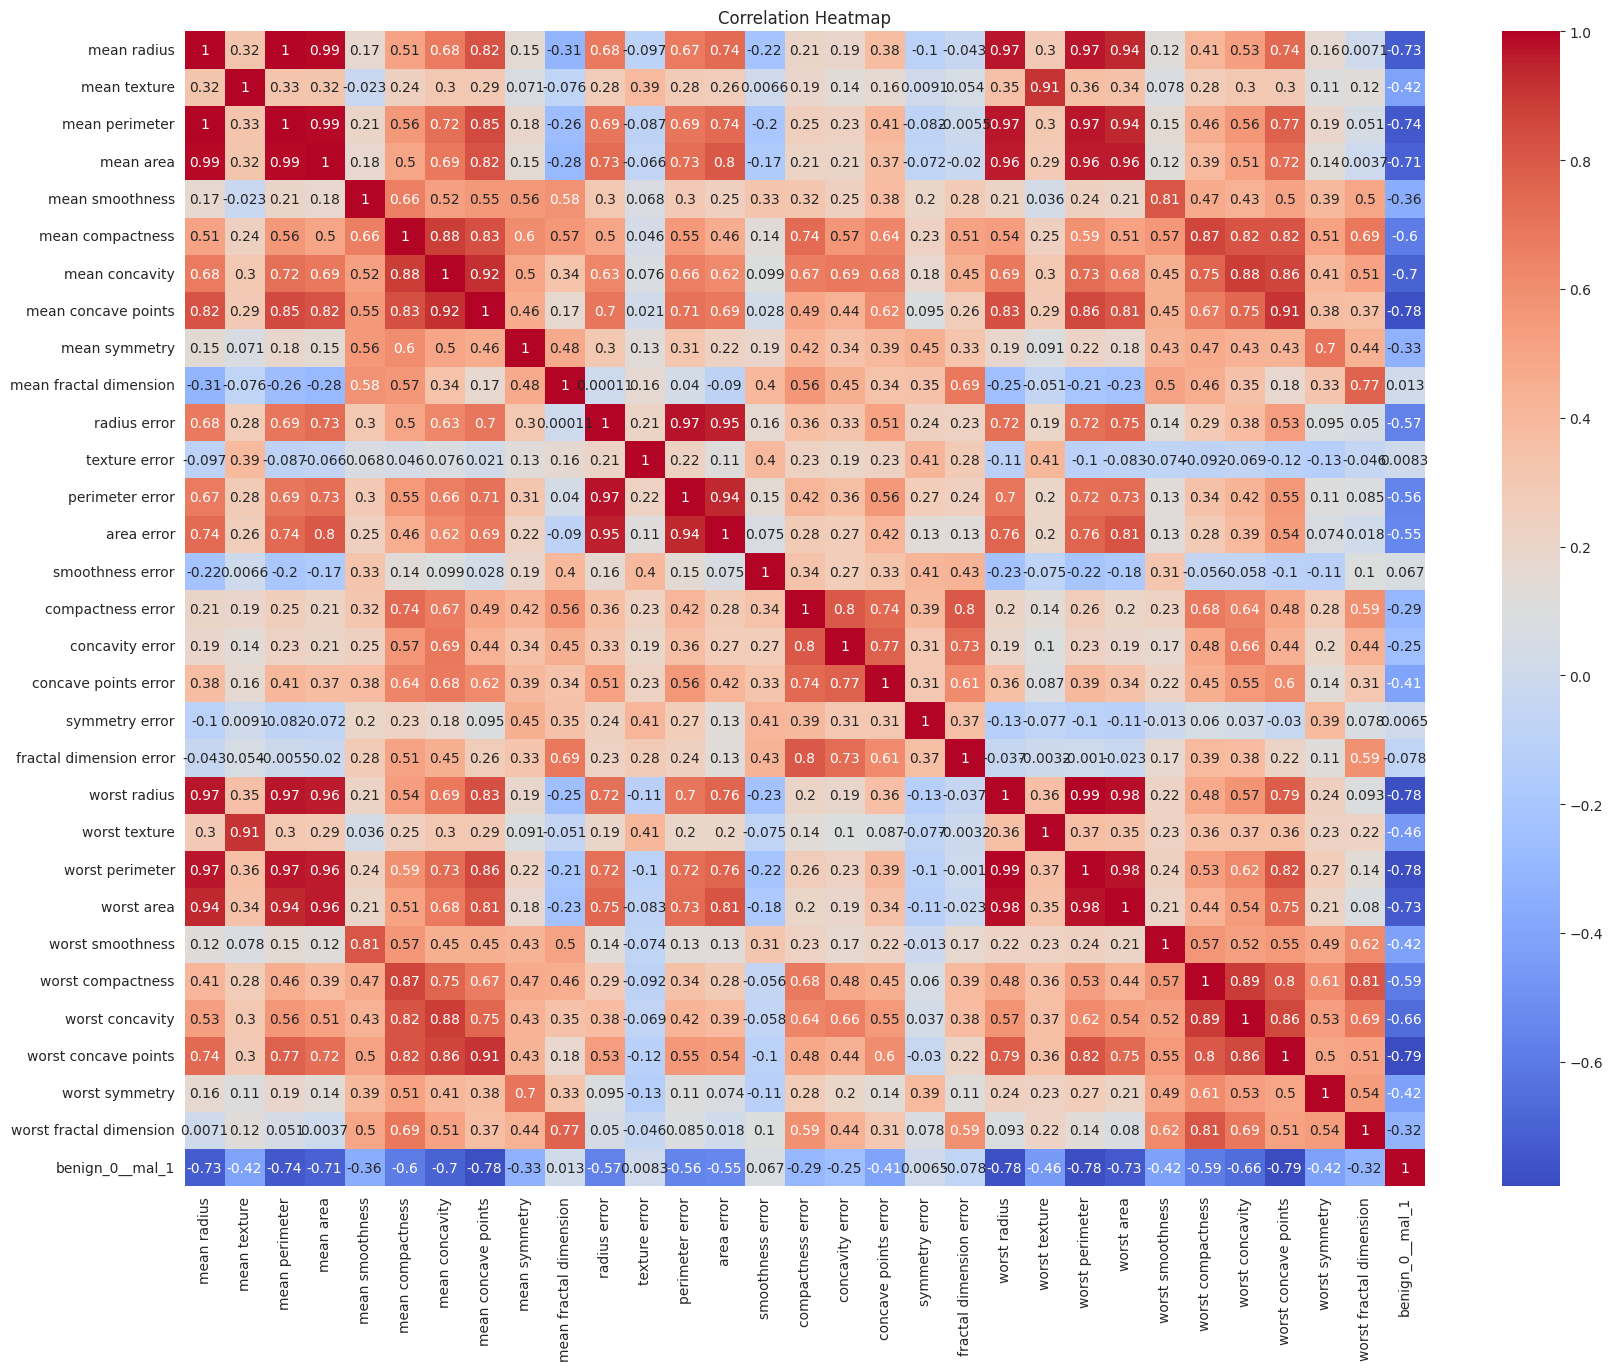

In [18]:

print(df.head())

# Describe dataset
print(df.describe().T)

# Class balance
fig = plt.figure(figsize=(10, 10))
sns.countplot(x='benign_0__mal_1', data=df)
plt.title('Class Distribution')
plt.show()

# Feature correlations
corr_matrix = df.corr()

# Correlation with target
df_corr = corr_matrix['benign_0__mal_1'].sort_values()

fig = plt.figure(figsize=(20, 10))
sns.barplot(x=df_corr.values, y=df_corr.index, orient='h')
plt.title('Feature Correlation with Target')
plt.show()

# Full heatmap
fig = plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [19]:

X = df.drop('benign_0__mal_1', axis=1)
y = df['benign_0__mal_1']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (fit only on training set to prevent leakage)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [20]:

model = Sequential([
    Dense(units=30, activation='relu'),
    Dense(units=15, activation='relu'),
    Dense(units=1, activation='sigmoid')  # Binary classification output
])

model.compile(loss='binary_crossentropy', optimizer='adam')

model.fit(X_train_scaled, y_train, epochs=600, validation_data=(X_test_scaled, y_test), verbose=0)


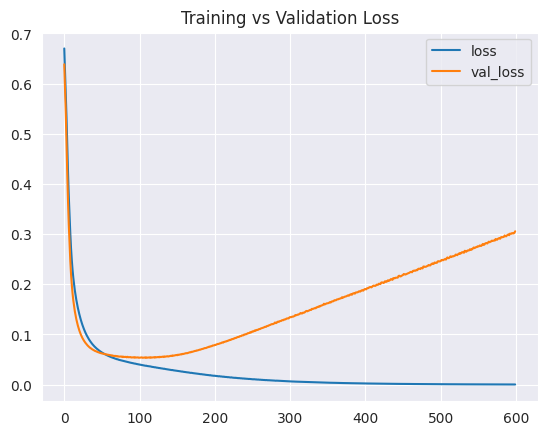

In [21]:

losses = pd.DataFrame(model.history.history)
losses.plot()
plt.title('Training vs Validation Loss')
plt.show()


In [22]:

model = Sequential([
    Dense(units=30, activation='relu'),
    Dense(units=15, activation='relu'),
    Dense(units=1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam')

early_stopping = EarlyStopping(monitor='val_loss', mode='min', patience=25, restore_best_weights=True, verbose=1)

model.fit(X_train_scaled, y_train, epochs=600, validation_data=(X_test_scaled, y_test), callbacks=[early_stopping], verbose=0)


Epoch 127: early stopping
Restoring model weights from the end of the best epoch: 102.


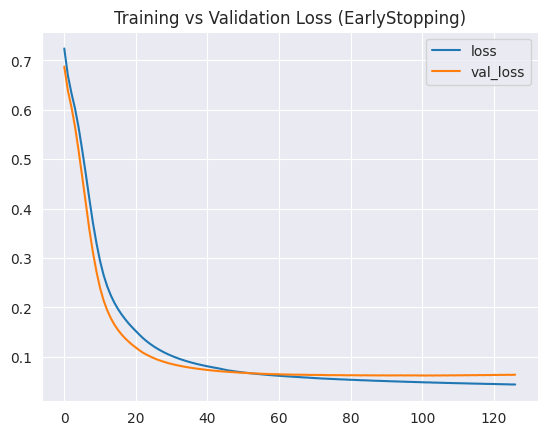

In [23]:

history = pd.DataFrame(model.history.history)
history[['loss', 'val_loss']].plot()
plt.title('Training vs Validation Loss (EarlyStopping)')
plt.show()


In [24]:

model = Sequential([
    Dense(units=30, activation='relu'),
    Dropout(0.5),
    Dense(units=15, activation='relu'),
    Dropout(0.5),
    Dense(units=1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam')

model.fit(X_train_scaled, y_train, epochs=600, validation_data=(X_test_scaled, y_test), callbacks=[early_stopping], verbose=0)


Epoch 150: early stopping
Restoring model weights from the end of the best epoch: 125.


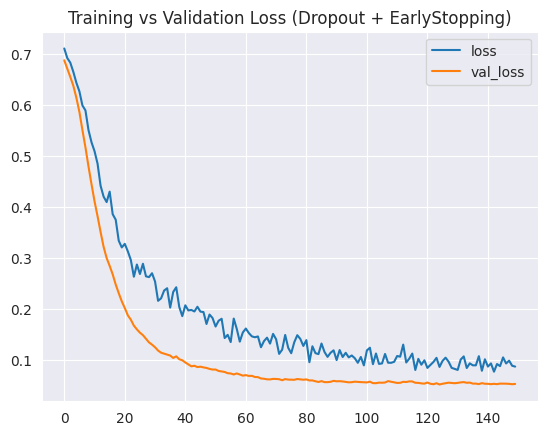

In [25]:

history = pd.DataFrame(model.history.history)
history[['loss', 'val_loss']].plot()
plt.title('Training vs Validation Loss (Dropout + EarlyStopping)')
plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



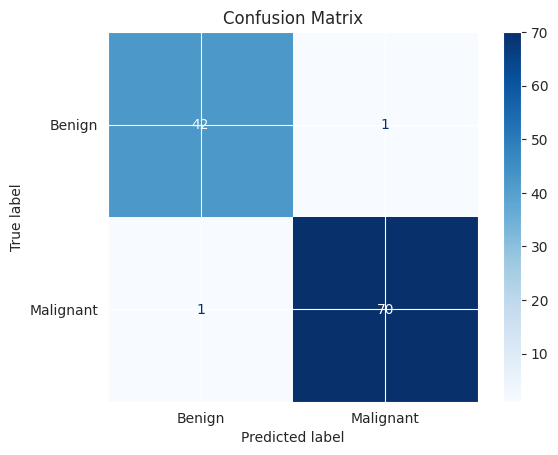

In [26]:

y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [27]:

tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Accuracy: 0.9825
Precision: 0.9859
Recall: 0.9859
F1-Score: 0.9859


In [28]:

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
print(f"Computed class weights: {dict(zip(np.unique(y_train), class_weights))}")
# (Not applied here, but ready for future imbalance handling.)


Computed class weights: {0: 1.3461538461538463, 1: 0.7954545454545454}


In [29]:
"""
Cancer Classification with Keras (TensorFlow backend)
-------------------------------------------------------

This notebook demonstrates a basic supervised learning pipeline for binary classification
(malignant vs benign tumors) using the UCI Breast Cancer dataset (via Udemy codealong).

It covers:
- Data loading and exploration
- Data preprocessing (scaling)
- Building simple neural networks (with/without regularization)
- Training with EarlyStopping
- Model evaluation (accuracy, confusion matrix, precision, recall, F1)

All models are intentionally kept simple for educational purposes.
"""


'\nCancer Classification with Keras (TensorFlow backend)\n-------------------------------------------------------\n\nThis notebook demonstrates a basic supervised learning pipeline for binary classification\n(malignant vs benign tumors) using the UCI Breast Cancer dataset (via Udemy codealong).\n\nIt covers:\n- Data loading and exploration\n- Data preprocessing (scaling)\n- Building simple neural networks (with/without regularization)\n- Training with EarlyStopping\n- Model evaluation (accuracy, confusion matrix, precision, recall, F1)\n\nAll models are intentionally kept simple for educational purposes.\n'

In [30]:
# Basic Libraries
import pandas as pd
import numpy as np
import re

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import ConfusionMatrixDisplay

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [31]:
# Load Dataset
DATA_PATH = '/mnt/mls/data/udemy/cancer_classification.csv'

df = pd.read_csv(DATA_PATH)


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

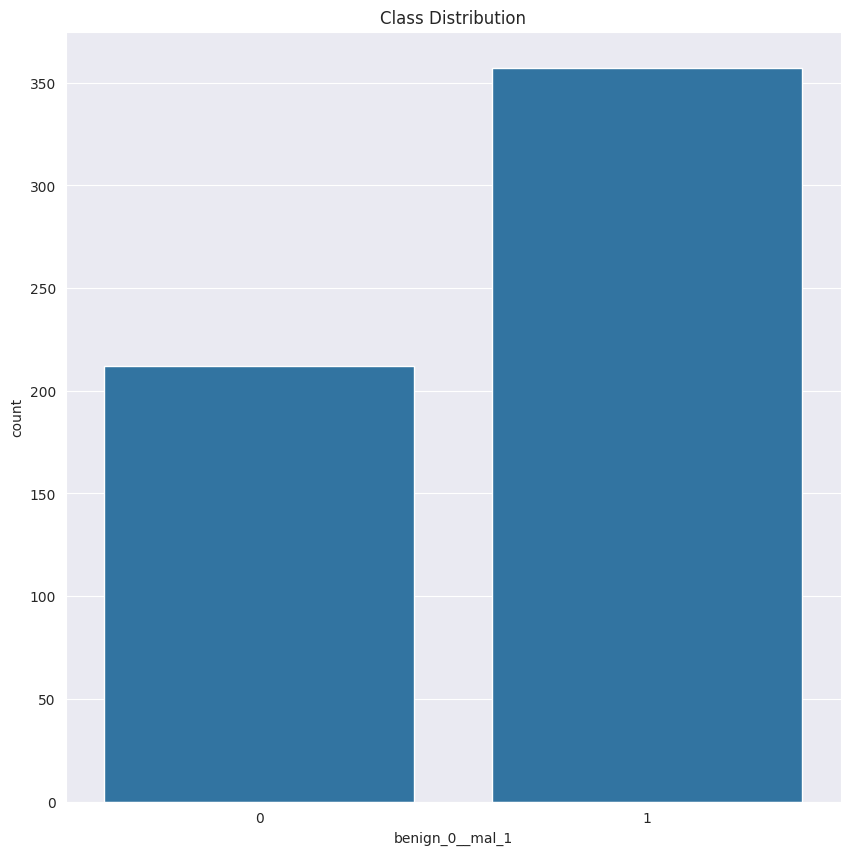

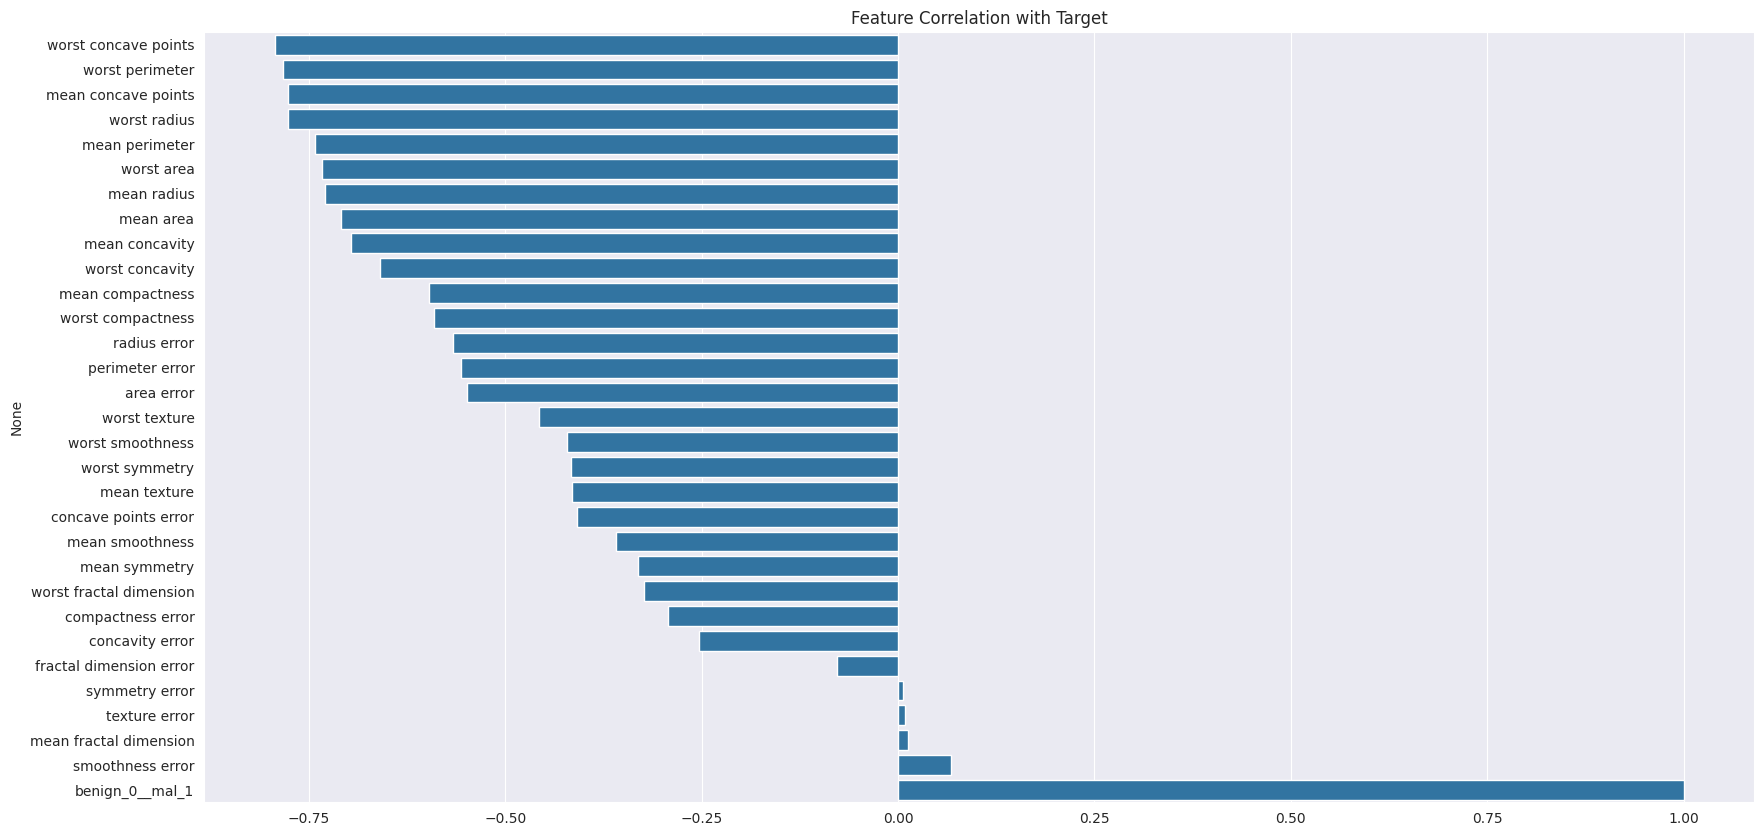

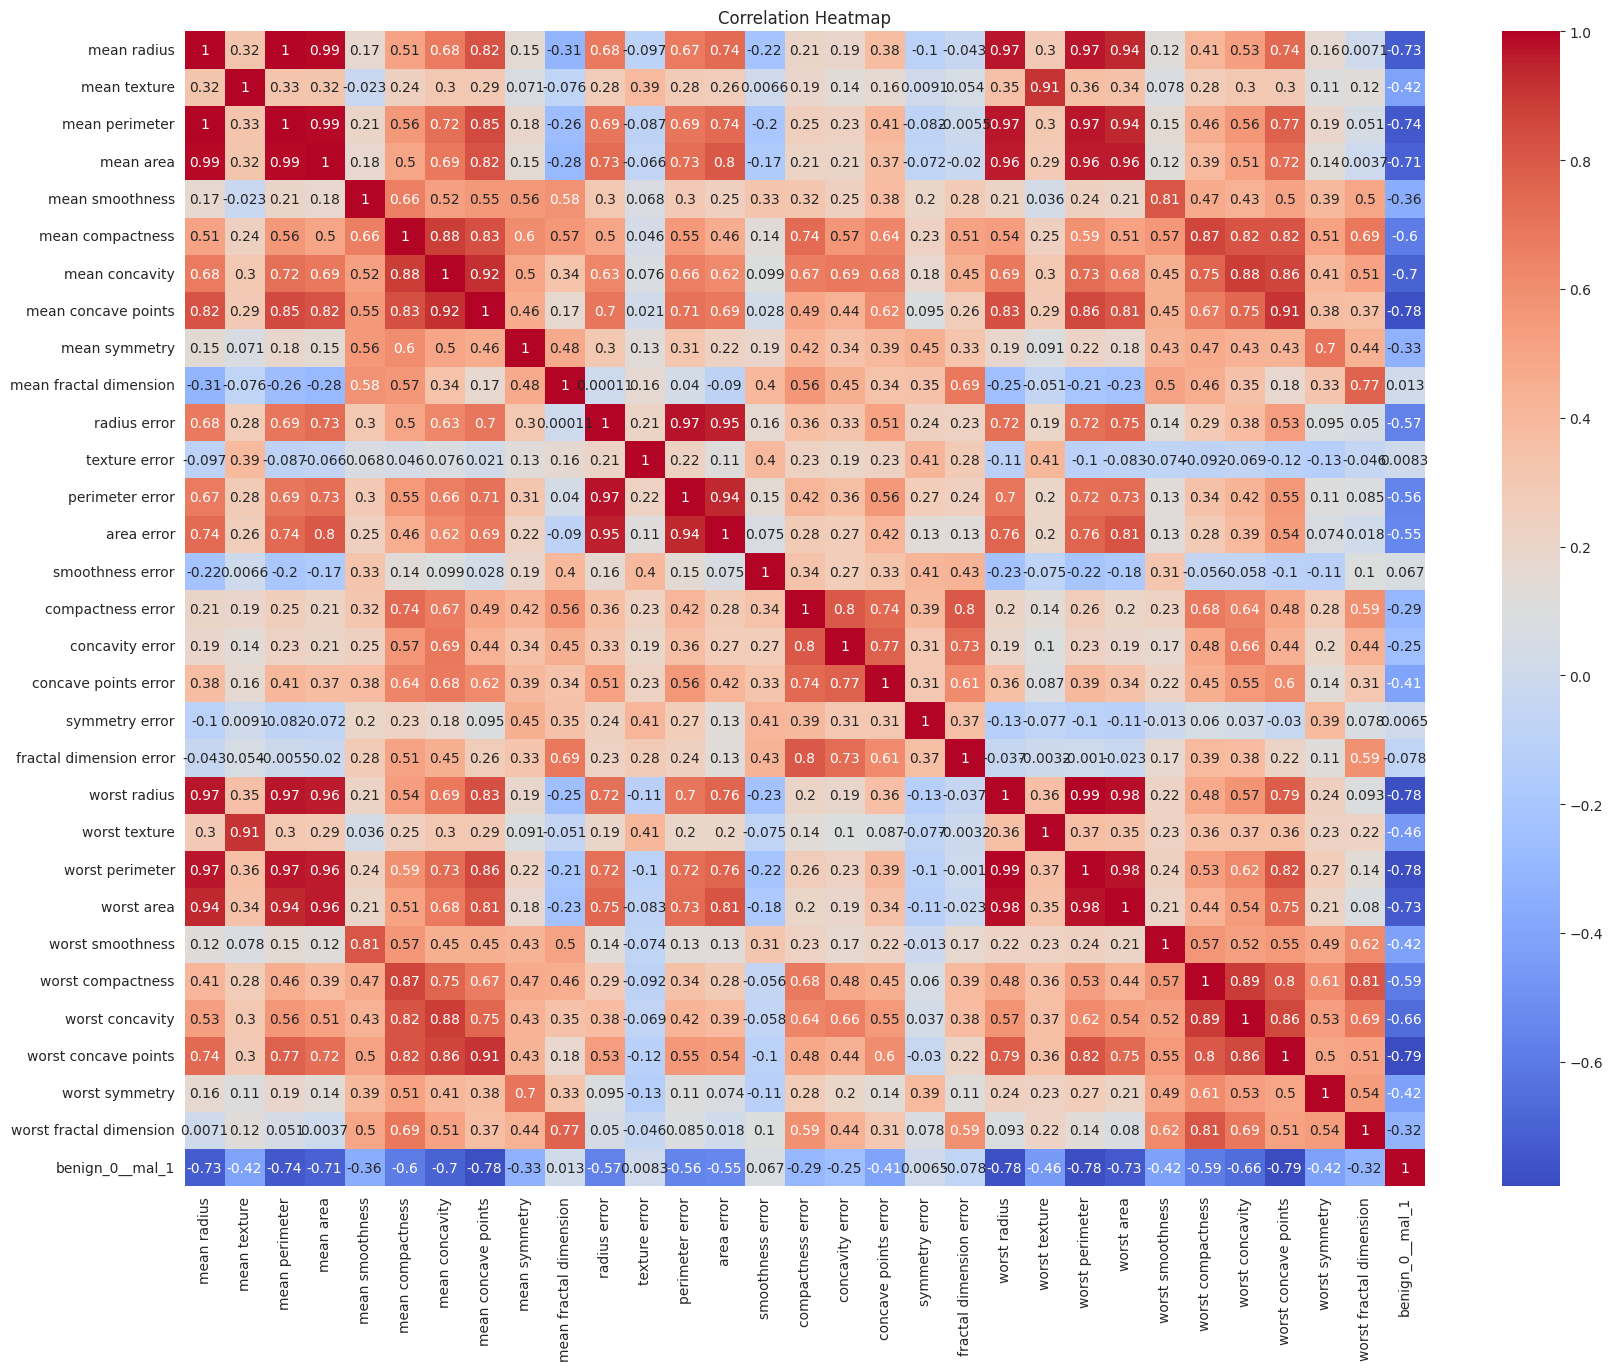

In [32]:
# Exploratory Data Analysis
print(df.head())
print(df.describe().T)

# Class balance
fig = plt.figure(figsize=(10, 10))
sns.countplot(x='benign_0__mal_1', data=df)
plt.title('Class Distribution')
plt.show()

# Feature correlations
corr_matrix = df.corr()

df_corr = corr_matrix['benign_0__mal_1'].sort_values()
fig = plt.figure(figsize=(20, 10))
sns.barplot(x=df_corr.values, y=df_corr.index, orient='h')
plt.title('Feature Correlation with Target')
plt.show()

# Full heatmap
fig = plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [33]:
# Data Preparation
X = df.drop('benign_0__mal_1', axis=1)
y = df['benign_0__mal_1']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
# Initial Model Training
model = Sequential([
    Dense(units=30, activation='relu'),
    Dense(units=15, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam')
model.fit(X_train_scaled, y_train, epochs=600, validation_data=(X_test_scaled, y_test), verbose=0)


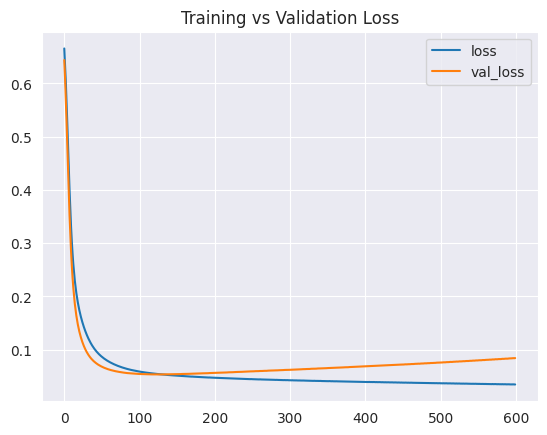

In [35]:
# Initial Loss Plot
losses = pd.DataFrame(model.history.history)
losses.plot()
plt.title('Training vs Validation Loss')
plt.show()


In [36]:
# Model with EarlyStopping
model = Sequential([
    Dense(units=30, activation='relu'),
    Dense(units=15, activation='relu'),
    Dense(units=1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam')

early_stopping = EarlyStopping(monitor='val_loss', mode='min', patience=25, restore_best_weights=True, verbose=1)
model.fit(X_train_scaled, y_train, epochs=600, validation_data=(X_test_scaled, y_test), callbacks=[early_stopping], verbose=0)


Epoch 135: early stopping
Restoring model weights from the end of the best epoch: 110.


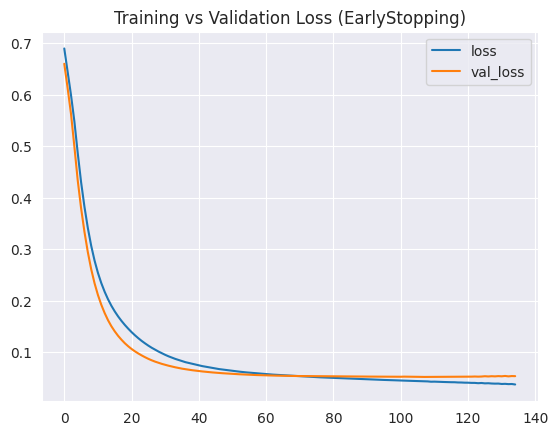

In [37]:
# EarlyStopping Loss Plot
history = pd.DataFrame(model.history.history)
history[['loss', 'val_loss']].plot()
plt.title('Training vs Validation Loss (EarlyStopping)')
plt.show()


In [38]:
# Model with Dropout Regularization
model = Sequential([
    Dense(units=30, activation='relu'),
    Dropout(0.5),
    Dense(units=15, activation='relu'),
    Dropout(0.5),
    Dense(units=1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam')

model.fit(X_train_scaled, y_train, epochs=600, validation_data=(X_test_scaled, y_test), callbacks=[early_stopping], verbose=0)


Epoch 168: early stopping
Restoring model weights from the end of the best epoch: 143.


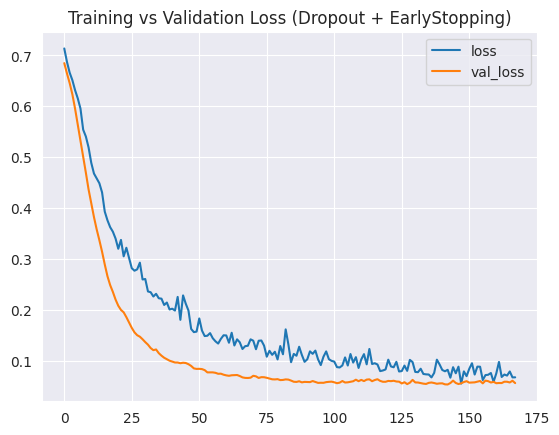

In [39]:
# Final Loss Plot (Dropout)
history = pd.DataFrame(model.history.history)
history[['loss', 'val_loss']].plot()
plt.title('Training vs Validation Loss (Dropout + EarlyStopping)')
plt.show()


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x792b2856ade0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                         

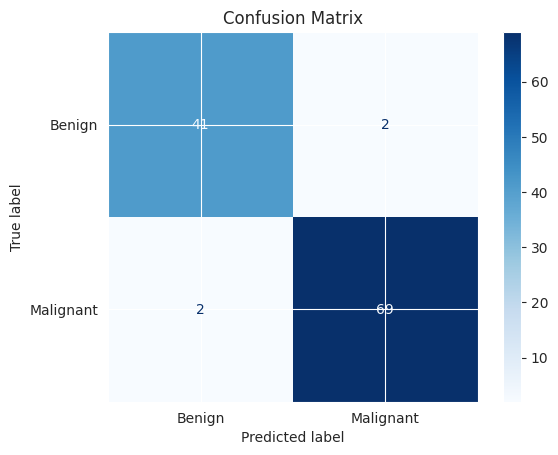

In [40]:
# Predictions and Evaluation
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [41]:
# Manual Metrics Calculation
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Accuracy: 0.9649
Precision: 0.9718
Recall: 0.9718
F1-Score: 0.9718


In [42]:
# Class Weights Calculation
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
print(f"Computed class weights: {dict(zip(np.unique(y_train), class_weights))}")
# (Not applied here, but ready for future imbalance handling.)

Computed class weights: {0: 1.3461538461538463, 1: 0.7954545454545454}
